# exp6_paddleV6Craft_kamus 2

Versi ekstraksi teks dari **kamus** sampai **endfunction** / **endprocedure** / **endprogram**.


In [6]:
from google.colab import drive
import os

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Google Drive sudah ter-mount di /content/drive")

Google Drive sudah ter-mount di /content/drive


### KONFIGURASI

In [7]:
CONFIG = {
    "dataset_path": "/content/drive/MyDrive/PDP_OCR_2/exp6_paddleV6CRAFT/DATASET_BagusGT/IMAGES",
    "result_path": "/content/drive/MyDrive/PDP_OCR_2/exp6_paddleV6CRAFT/resultBagus",
    "supported_ext": (".jpg", ".jpeg", ".png"),
    "start_index": 0,
    "limit": None,
    "gt_only": True,
    "gt_path": "/content/drive/MyDrive/PDP_OCR_2/exp6_paddleV6CRAFT/DATASET_BagusGT/GT",
    "gt_extension": ".md",
    "lang": "en",
    "device": "gpu:0",
    "use_doc_orientation_classify": False,
    "use_doc_unwarping": False,
    "use_textline_orientation": True,
    "text_det_thresh": 0.3,
    "text_det_box_thresh": 0.6,
    "text_det_unclip_ratio": 1.5,
    "text_rec_score_thresh": 0.0,
}


In [ ]:
import os
os.makedirs(CONFIG["result_path"], exist_ok=True)


### Instalasi PaddleOCR (Recognition) + CRAFT (Detection)

In [ ]:
# Check GPU / CUDA info
!nvidia-smi --query-gpu=name,driver_version --format=csv,noheader 2>/dev/null || echo "No GPU detected"
!python -c "import torch; print('CUDA runtime:', torch.version.cuda)" 2>/dev/null || echo "torch not installed yet"

# Install PaddlePaddle GPU (CUDA 12.6)
!pip install -q paddlepaddle-gpu -i https://www.paddlepaddle.org.cn/packages/stable/cu126/

# Install PaddleOCR
!pip install -q "paddleocr>=3.0.0"

# Install PyTorch stack — aligned to CUDA 12.1 wheels
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --upgrade

# CRAFT text detector (no deps, to avoid clobbering the torch version above)
!pip install -q --no-deps craft-text-detector

!pip install -q gdown

Tesla T4, 580.82.07
CUDA runtime: 12.8
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 GB 745.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 5.3 MB/s eta 0:

### IMPORT LIBRARY

In [5]:
import os
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

import time
import cv2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image, ImageDraw
if 'TextRecognition' not in globals():
    from paddleocr import TextRecognition

### MONKEY PATCHES UNTUK DEPENDENSI INTERNAL (CRAFT & TORCHVISION)

In [8]:
import collections
import collections.abc
for _name in ("Mapping", "MutableMapping", "Sequence", "Iterable"):
    if not hasattr(collections, _name):
        setattr(collections, _name, getattr(collections.abc, _name))

import torch
import torchvision.models as _tv_models
import torchvision.models.vgg as _tv_vgg

if not getattr(_tv_vgg, "_craft_patch_applied", False):
    if not hasattr(_tv_vgg, "model_urls"):
        _tv_vgg.model_urls = {
            "vgg11": "https://download.pytorch.org/models/vgg11-8a719046.pth",
            "vgg13": "https://download.pytorch.org/models/vgg13-19584684.pth",
            "vgg16": "https://download.pytorch.org/models/vgg16-397923af.pth",
            "vgg19": "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth",
            "vgg11_bn": "https://download.pytorch.org/models/vgg11_bn-6002323d.pth",
            "vgg13_bn": "https://download.pytorch.org/models/vgg13_bn-abd245e5.pth",
            "vgg16_bn": "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth",
            "vgg19_bn": "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth",
        }

    _true_orig_vgg16_bn = _tv_vgg.vgg16_bn


    def _patched_vgg16_bn(pretrained=False, progress=True, **kwargs):
        kwargs.pop("weights", None)
        try:
            return _true_orig_vgg16_bn(
                weights="IMAGENET1K_V1" if pretrained else None,
                progress=progress,
                **kwargs,
            )
        except TypeError:
            return _true_orig_vgg16_bn(pretrained=pretrained, progress=progress, **kwargs)

    _tv_models.vgg16_bn = _patched_vgg16_bn
    _tv_vgg.vgg16_bn = _patched_vgg16_bn
    _tv_vgg._craft_patch_applied = True

if not getattr(torch, "_craft_load_patch_applied", False):
    _orig_torch_load = torch.load
    def _patched_torch_load(*args, **kwargs):
        kwargs.setdefault("weights_only", False)
        return _orig_torch_load(*args, **kwargs)
    torch.load = _patched_torch_load
    torch._craft_load_patch_applied = True

if 'Craft' not in globals():
    from craft_text_detector import Craft

import contextlib

@contextlib.contextmanager
def numpy_allow_ragged():
    _orig_array = np.array
    def _patched_array(obj, *args, **kwargs):
        try:
            return _orig_array(obj, *args, **kwargs)
        except ValueError as e:
            if "inhomogeneous" in str(e) or "sequence" in str(e):
                kwargs["dtype"] = object
                return _orig_array(obj, *args, **kwargs)
            raise
    np.array = _patched_array
    try:
        yield
    finally:
        np.array = _orig_array

### INISIALISASI MODEL

In [9]:
# ---- CRAFT (deteksi bounding box) ----
_craft_use_cuda = CONFIG["device"].startswith("gpu") and torch.cuda.is_available()
if CONFIG["device"].startswith("gpu") and not torch.cuda.is_available():
    print("[INFO] CONFIG['device'] diset ke GPU tapi CUDA tidak tersedia di runtime ini, CRAFT dijalankan di CPU.")

if 'craft' not in globals():
    craft = Craft(
        output_dir=None,
        crop_type="box",
        cuda=_craft_use_cuda,
        text_threshold=CONFIG["text_det_thresh"],
        low_text=CONFIG["text_det_box_thresh"],
    )

def build_text_recognizer(device):
    try:
        return TextRecognition(model_name="PP-OCRv6_medium_rec", device=device)
    except Exception:

        return TextRecognition(device=device)

if 'text_recognizer' not in globals():
    try:
        text_recognizer = build_text_recognizer(CONFIG["device"])
    except Exception as e:
        print(f"GPU gagal ({e}), fallback ke CPU")
        text_recognizer = build_text_recognizer("cpu")

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.
/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


### HELPER FUNCTION

In [10]:
def draw_boxes(image, boxes, texts=None, scores=None):
    img = image.copy()
    draw = ImageDraw.Draw(img)
    for i, box in enumerate(boxes):
        pts = np.array(box).astype(np.int32).reshape(-1, 2)
        draw.polygon([tuple(p) for p in pts], outline="red", width=3)
        if texts is not None:
            label = texts[i] if scores is None else f"{texts[i]} ({scores[i]:.2f})"
            draw.text((pts[0][0], max(pts[0][1] - 15, 0)), label, fill="blue")
    return img


def show_image(img, title):
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def crop_polygon(image_np, box):
    pts = np.array(box).astype(np.float32)
    x_min = max(int(np.min(pts[:, 0])), 0)
    y_min = max(int(np.min(pts[:, 1])), 0)
    x_max = min(int(np.max(pts[:, 0])), image_np.shape[1])
    y_max = min(int(np.max(pts[:, 1])), image_np.shape[0])
    crop = image_np[y_min:y_max, x_min:x_max]
    if crop.size == 0:
        return crop
    return cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)


def reconstruct_indentation(boxes, texts, tolerance=45, use_indent=True):
    if not boxes or not texts:
        return ""

    data = []
    for box, text in zip(boxes, texts):
        x_coords = [pt[0] for pt in box]
        y_coords = [pt[1] for pt in box]
        x_min = min(x_coords)
        y_center = sum(y_coords) / 4.0
        h = max(y_coords) - min(y_coords)
        data.append({"x": x_min, "y": y_center, "h": h, "text": text})

    data.sort(key=lambda item: item["y"])

    lines = []
    current_line = [data[0]]

    for item in data[1:]:
        prev_item = current_line[-1]
        if abs(item["y"] - prev_item["y"]) < max(item["h"], prev_item["h"]) * 0.5:
            current_line.append(item)
        else:
            lines.append(current_line)
            current_line = [item]
    lines.append(current_line)

    first_x_list = sorted([line[0]["x"] for line in lines])

    clusters = []
    if first_x_list:
        current_cluster = [first_x_list[0]]
        for x in first_x_list[1:]:
            if x - current_cluster[0] <= tolerance:
                current_cluster.append(x)
            else:
                clusters.append(current_cluster)
                current_cluster = [x]
        clusters.append(current_cluster)

    def get_indent_level(x_val):
        for i, cluster in enumerate(clusters):
            if x_val in cluster:
                return i
        return 0

    result_lines = []
    for line in lines:
        line.sort(key=lambda item: item["x"])
        first_x = line[0]["x"]

        level = get_indent_level(first_x) if use_indent else 0

        line_str = "    " * level + line[0]["text"]

        for i in range(1, len(line)):
            line_str += " " + line[i]["text"]

        result_lines.append(line_str)

    return "\n".join(result_lines)


def extract_kamus_to_end(text):
    if not text:
        return text

    lines = text.splitlines()
    end_keywords = ("endfunction", "endprocedure", "endprogram")
    extracted_blocks = []
    i = 0
    n = len(lines)

    while i < n:
        line_lower = lines[i].lower()
        if "kamus" in line_lower:
            kamus_idx = i
            end_idx = -1
            for j in range(kamus_idx, n):
                j_lower = lines[j].lower()
                if any(kw in j_lower for kw in end_keywords):
                    end_idx = j
                    break

            if end_idx != -1:
                extracted_blocks.append(lines[kamus_idx : end_idx + 1])
                i = end_idx + 1
            else:
                extracted_blocks.append(lines[kamus_idx:])
                break
        else:
            i += 1

    if not extracted_blocks:
        return text

    result_lines = []
    for block in extracted_blocks:
        result_lines.extend(block)

    return "\n".join(result_lines)


def write_raw_markdown(image_name, text_content):
    md_path = os.path.join(CONFIG["result_path"], os.path.splitext(image_name)[0] + ".md")
    with open(md_path, "w", encoding="utf-8") as f:
        f.write(text_content)


### MAIN FUNCTION

In [11]:
def process_ocr(image_name, index, total):
    img_path = os.path.join(CONFIG["dataset_path"], image_name)

    start = time.perf_counter()

    image = Image.open(img_path).convert('RGB')
    image_np = np.array(image)

    # STEP 0: Deteksi bounding box dengan CRAFT (menggantikan detektor bawaan PaddleOCR)
    with numpy_allow_ragged():
        craft_result = craft.detect_text(image=img_path)
    # PENTING: konversi ke list Python biasa. numpy_allow_ragged() bisa
    # mengembalikan boxes sebagai numpy array dtype=object, dan itu bikin
    # `if not boxes` di reconstruct_indentation() error ("truth value of an
    # array... is ambiguous") karena numpy array tidak bisa dicek truthy
    # langsung kalau isinya lebih dari 1 elemen.
    boxes = list(craft_result["boxes"])

    # STEP 0b: Baca teks tiap box pakai PP-OCRv6 (recognition-only)
    texts, scores = [], []
    for box in boxes:
        crop = crop_polygon(image_np, box)
        if crop.size == 0:
            texts.append("")
            scores.append(0.0)
            continue
        rec_output = list(text_recognizer.predict(input=crop))
        if rec_output:
            texts.append(rec_output[0]["rec_text"])
            scores.append(rec_output[0]["rec_score"])
        else:
            texts.append("")
            scores.append(0.0)

    # Filter berdasarkan skor recognition (setara text_rec_score_thresh di exp5)
    if CONFIG["text_rec_score_thresh"] > 0:
        filtered = [
            (b, t, s) for b, t, s in zip(boxes, texts, scores)
            if s >= CONFIG["text_rec_score_thresh"]
        ]
        boxes = [f[0] for f in filtered]
        texts = [f[1] for f in filtered]
        scores = [f[2] for f in filtered]

    elapsed = time.perf_counter() - start

    print(f"\n[{index}/{total}] {image_name} — {elapsed:.2f}s")
    print("=" * 50)

    if len(boxes) == 0:
        print("Tidak ada teks terdeteksi")
        return

    # STEP 1: Bounding Box (CRAFT)
    box_only = draw_boxes(image, boxes)
    print(f"Step 1: Deteksi bounding box selesai ({len(boxes)} box) [CRAFT]")
    show_image(box_only, f"{image_name} — Step 1: Bounding Box (CRAFT)")

    # STEP 2: Hasil Recognition (Raw Text) [PP-OCRv6]
    print("\nStep 2: Hasil Recognition (Raw Text) [PP-OCRv6]")
    print("-" * 30)
    for i, t in enumerate(texts, 1):
        print(f"{i}. {t}")

    # STEP 3: Post-Processing Indentasi + Pengecualian
    base_name = os.path.splitext(image_name)[0]
    # Cek apakah nama file berakhiran '4_jawaban' atau 'penjelasan'
    if base_name.endswith("4_jawaban") or base_name.endswith("penjelasan"):
        use_indent = False
        print("\n[INFO] File terdeteksi narasi/penjelasan. Indentasi dinonaktifkan (Rata Kiri).")
    else:
        use_indent = True

    print("\nStep 3: Hasil Rekonstruksi Teks")
    print("-" * 30)
    reconstructed_text = reconstruct_indentation(boxes, texts, tolerance=45, use_indent=use_indent)
    print(reconstructed_text)
    print("=" * 50)

    # STEP 4: Ekstraksi Teks (Kamus -> End)
    print("\nStep 4: Ekstraksi Teks (Kamus -> End)")
    print("-" * 30)
    cleaned_text = extract_kamus_to_end(reconstructed_text)
    print(cleaned_text)
    print("=" * 50)

    # STEP 5: Simpan file markdown mentahan
    write_raw_markdown(image_name, cleaned_text)
    print(f"File mentahan tersimpan: {base_name}.md")


### EKSEKUSI PIPELINE

In [12]:
def has_gt(filename):
    base = os.path.splitext(filename)[0]
    return os.path.exists(os.path.join(CONFIG["gt_path"], base + CONFIG["gt_extension"]))


if os.path.exists(CONFIG["dataset_path"]):
    files = sorted(f for f in os.listdir(CONFIG["dataset_path"]) if f.lower().endswith(CONFIG["supported_ext"]))

    if CONFIG["gt_only"]:
        files = [f for f in files if has_gt(f)]

    start = CONFIG["start_index"]
    end = start + CONFIG["limit"] if CONFIG["limit"] else None
    files = files[start:end]

    total = len(files)
    print(f"Total foto yang akan diproses: {total}")
    print(f"Rentang index: {start} - {start + total - 1}")
    print(f"GT only: {CONFIG['gt_only']}")
    print("Daftar file:")
    for i, f in enumerate(files, start + 1):
        print(f"  [{i}] {f}")
    print("-" * 40)

    for idx, file in enumerate(files, 1):
        try:
            process_ocr(file, idx, total)
        except Exception as e:
            print(f"Skip {file}: {e}")
else:
    print(f"Dataset path not found: {CONFIG['dataset_path']}")

Output hidden; open in https://colab.research.google.com to view.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### BENCHMARK TEST

Streaming output truncated to the last 5000 lines.
  - WER Standard   : 22/33 kata (66.67%)
  - WER Normalized : 15/25 kata (60.00%)
  - Keyword Acc    : 11/14 kata kunci (78.6%)
--------------------------------------------------------------------------------

[209/304] DETAIL BENCHMARK: if4909_103012500345_1a_jawaban.md

[LANGKAH 1] TEKS HASIL EKSTRAKSI (kamus -> end...)
------------------------------------------------------------
--- Ground Truth (Kamus -> End) ---
kamus
	totalBunga, tagihan, besarCicilan : integer

algoritma
	totalBunga = totalBelanja *(bunga)
	tagihan = totalBelanja + totalBunga
	besarCicilan = tagihan * tenor + admin
	return besarCicilan

endfunction

--- OCR Text (Kamus -> End) ---
kamus
    totalBunga，tagihan，besar Cicilan:integer
algoritma
    totalBunga = totalBelanja *(bunga
    tagihan = totalBelanja + totalbunga
    besarCicilan = tagihan * tenor + admin
    return besarCicilan
endfunction

[LANGKAH 2] ANALISIS KATA BERBEDA & PERHITUNGAN CER + WER
---------

,File Name,CER Std,CER Norm,WER Std,WER Norm,KW Acc
0,if4901_103011500026_1a_jawaban.md,25/173 (14.45%),2/148 (1.35%),6/29 (20.69%),1/20 (5.00%),12/13 (92.3%)
1,if4901_103011500026_2a_jawaban.md,24/194 (12.37%),14/174 (8.05%),11/22 (50.00%),8/18 (44.44%),5/9 (55.6%)
2,if4901_103011500026_2b_jawaban.md,8/364 (2.20%),3/290 (1.03%),4/46 (8.70%),3/36 (8.33%),25/26 (96.2%)
3,if4901_103011500026_3_jawaban.md,28/92 (30.43%),20/64 (31.25%),11/15 (73.33%),8/13 (61.54%),4/6 (66.7%)
4,if4901_103011500125_1a_jawaban.md,75/313 (23.96%),18/243 (7.41%),31/42 (73.81%),19/29 (65.52%),10/15 (66.7%)
5,if4901_103012400403_3_jawaban.md,113/293 (38.57%),49/160 (30.63%),33/43 (76.74%),26/35 (74.29%),5/13 (38.5%)
6,if4901_103012500001_1a_jawaban.md,143/192 (74.48%),108/145 (74.48%),27/28 (96.43%),16/19 (84.21%),11/12 (91.7%)
7,if4901_103012500001_1b_jawaban.md,76/254 (29.92%),13/168 (7.74%),25/41 (60.98%),12/28 (42.86%),11/18 (61.1%)
8,if4901_103012500001_3_jawaban.md,22/158 (13.92%),19/106 (17.92%),14/24 (58.33%),11/21 (52.38%),5/7 (71.4%)
9,if4901_103012500018_1a_jawaban.md,52/246 (21.14%),17/197 (8.63%),18/31 (58.06%),11/21 (52.38%),8/13 (61.5%)



RINGKASAN STATISTIK AGREGAT


,Kategori,CER Std,CER Norm,WER Std,WER Norm,KW Acc
0,TOTAL AGREGAT (304 Files),23383/94104 (24.85%),10218/72254 (14.14%),6746/12382 (54.48%),4604/9805 (46.96%),3820/5308 (72.0%)
1,AVERAGE PER FILE,- (25.70%),- (14.91%),- (55.91%),- (48.62%),- (71.3%)


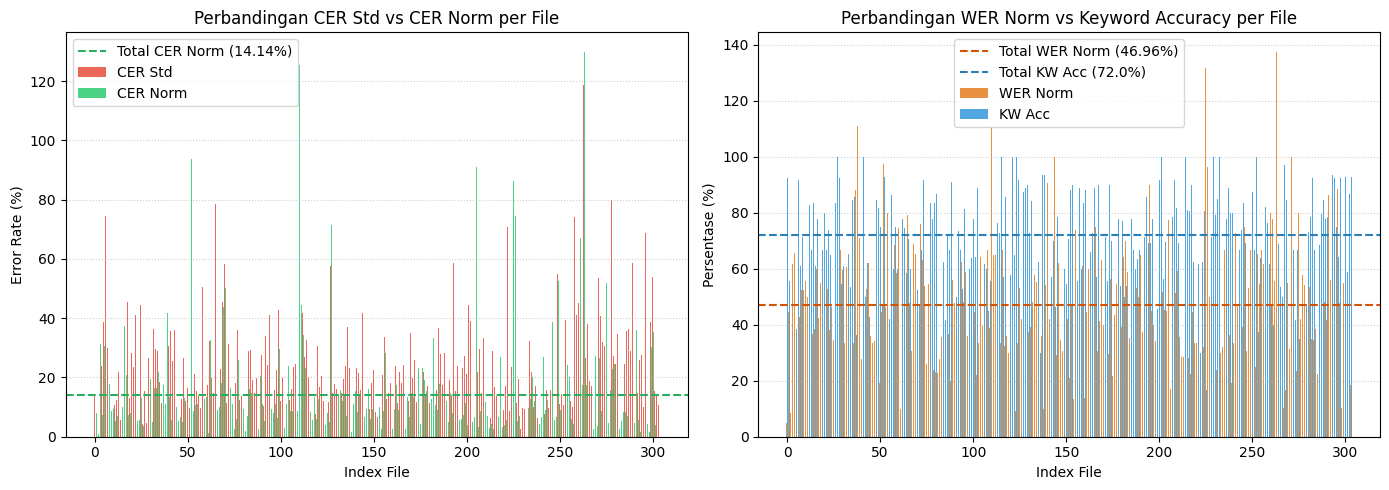

In [13]:
# ==============================================================================
# BENCHMARK & EVALUASI DETAIL SELURUH FILE (KAMUS -> END)
# ==============================================================================
import os
import re
import difflib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Aktifkan formatter tabel interaktif jika di Google Colab
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except Exception:
    pass

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
# Pastikan CONFIG terdefinisi meskipun cell atas belum dijalankan
if 'CONFIG' not in globals():
    CONFIG = {
        "dataset_path": "/content/drive/MyDrive/PDP_OCR_2/dataset/gb01_new",
        "result_path": "/content/drive/MyDrive/PDP_OCR_2/exp6_paddleV6CRAFT/result_gb01_new",
        "supported_ext": (".jpg", ".jpeg", ".png"),
        "start_index": 0,
        "limit": None,
        "gt_only": True,
        "gt_path": "/content/drive/MyDrive/PDP_OCR_2/groundtruth/gt01_new",
        "gt_extension": ".md",
        "lang": "en",
        "device": "gpu:0",
        "use_doc_orientation_classify": False,
        "use_doc_unwarping": False,
        "use_textline_orientation": True,
        "text_det_thresh": 0.3,
        "text_det_box_thresh": 0.6,
        "text_det_unclip_ratio": 1.5,
        "text_rec_score_thresh": 0.0,
    }


def levenshtein_dist(seq1, seq2):
    """Menghitung edit distance (Levenshtein) antara dua sekuens (string/list)."""
    if len(seq1) < len(seq2):
        return levenshtein_dist(seq2, seq1)
    if len(seq2) == 0:
        return len(seq1)

    prev_row = range(len(seq2) + 1)
    for i, c1 in enumerate(seq1):
        curr_row = [i + 1]
        for j, c2 in enumerate(seq2):
            ins = prev_row[j + 1] + 1
            it_del = curr_row[j] + 1
            sub = prev_row[j] + (c1 != c2)
            curr_row.append(min(ins, it_del, sub))
        prev_row = curr_row
    return prev_row[-1]

def clean_text_norm(text):
    """Normalisasi teks: lowercase, hapus tanda baca, standarisasi spasi."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_kamus_to_end(text):
    """Memotong teks hanya dari 'kamus' sampai 'endfunction/endprocedure/endprogram'."""
    if not text:
        return text
    lines = text.splitlines()
    end_keywords = ("endfunction", "endprocedure", "endprogram")
    extracted_blocks = []
    i = 0
    n = len(lines)

    while i < n:
        line_lower = lines[i].lower()
        if "kamus" in line_lower:
            kamus_idx = i
            end_idx = -1
            for j in range(kamus_idx, n):
                j_lower = lines[j].lower()
                if any(kw in j_lower for kw in end_keywords):
                    end_idx = j
                    break

            if end_idx != -1:
                extracted_blocks.append(lines[kamus_idx : end_idx + 1])
                i = end_idx + 1
            else:
                extracted_blocks.append(lines[kamus_idx:])
                break
        else:
            i += 1

    if not extracted_blocks:
        return text

    result_lines = []
    for block in extracted_blocks:
        result_lines.extend(block)

    return "\n".join(result_lines)

def get_word_differences(gt_text, ocr_text):
    """Mendeteksi kata-kata yang berbeda antara GT dan OCR yang memicu error CER/WER."""
    gt_words = clean_text_norm(gt_text).split()
    ocr_words = clean_text_norm(ocr_text).split()

    matcher = difflib.SequenceMatcher(None, gt_words, ocr_words)
    diffs = []
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'replace':
            gt_chunk = " ".join(gt_words[i1:i2])
            ocr_chunk = " ".join(ocr_words[j1:j2])
            diffs.append(f"Salah Baca (Substitusi) : GT '{gt_chunk}' -> OCR '{ocr_chunk}'")
        elif tag == 'delete':
            gt_chunk = " ".join(gt_words[i1:i2])
            diffs.append(f"Kata Hilang (Delesi)     : GT '{gt_chunk}' -> OCR [tidak terbaca]")
        elif tag == 'insert':
            ocr_chunk = " ".join(ocr_words[j1:j2])
            diffs.append(f"Kata Tambahan (Insersi)  : GT [tidak ada] -> OCR '{ocr_chunk}'")
    return diffs

def calculate_metrics(gt_text, ocr_text):
    """Menghitung seluruh metrik beserta detail pembilang dan penyebutnya."""
    gt_std = gt_text.strip()
    ocr_std = ocr_text.strip()
    c_dist_std = levenshtein_dist(gt_std, ocr_std)
    c_len_std = max(1, len(gt_std))
    cer_std = c_dist_std / c_len_std

    gt_words_std = gt_std.split()
    ocr_words_std = ocr_std.split()
    w_dist_std = levenshtein_dist(gt_words_std, ocr_words_std)
    w_len_std = max(1, len(gt_words_std))
    wer_std = w_dist_std / w_len_std

    gt_norm = clean_text_norm(gt_text)
    ocr_norm = clean_text_norm(ocr_text)
    c_dist_norm = levenshtein_dist(gt_norm, ocr_norm)
    c_len_norm = max(1, len(gt_norm))
    cer_norm = c_dist_norm / c_len_norm

    gt_words_norm = gt_norm.split()
    ocr_words_norm = ocr_norm.split()
    w_dist_norm = levenshtein_dist(gt_words_norm, ocr_words_norm)
    w_len_norm = max(1, len(gt_words_norm))
    wer_norm = w_dist_norm / w_len_norm

    gt_kw = set([w for w in gt_words_norm if len(w) > 2])
    ocr_kw = set(ocr_words_norm)
    matched_kw = gt_kw.intersection(ocr_kw) if gt_kw else set()
    kw_len = max(1, len(gt_kw))
    kw_acc = len(matched_kw) / kw_len if gt_kw else 1.0

    return {
        "c_dist_std": c_dist_std, "c_len_std": c_len_std, "cer_std": cer_std,
        "c_dist_norm": c_dist_norm, "c_len_norm": c_len_norm, "cer_norm": cer_norm,
        "w_dist_std": w_dist_std, "w_len_std": w_len_std, "wer_std": wer_std,
        "w_dist_norm": w_dist_norm, "w_len_norm": w_len_norm, "wer_norm": wer_norm,
        "kw_matched": len(matched_kw), "kw_total": len(gt_kw), "kw_acc": kw_acc,
    }

def benchmark_single_file(gt_content, ocr_content, file_name, index, total):
    """Memproses dan menampilkan detail benchmarking untuk 1 file."""
    print("=" * 80)
    print(f"[{index}/{total}] DETAIL BENCHMARK: {file_name}")
    print("=" * 80)

    # 1. Ekstraksi Kamus -> End
    gt_extracted = extract_kamus_to_end(gt_content)
    ocr_extracted = extract_kamus_to_end(ocr_content)

    print("\n[LANGKAH 1] TEKS HASIL EKSTRAKSI (kamus -> end...)")
    print("-" * 60)
    print("--- Ground Truth (Kamus -> End) ---")
    print(gt_extracted.strip() if gt_extracted.strip() else "(Kosong)")
    print("\n--- OCR Text (Kamus -> End) ---")
    print(ocr_extracted.strip() if ocr_extracted.strip() else "(Kosong)")

    # 2. Analisis Kata Berbeda & Metrik CER + WER
    diffs = get_word_differences(gt_extracted, ocr_extracted)
    m = calculate_metrics(gt_extracted, ocr_extracted)

    print("\n[LANGKAH 2] ANALISIS KATA BERBEDA & PERHITUNGAN CER + WER")
    print("-" * 60)
    if diffs:
        print("Kata-kata yang berbeda dengan Ground Truth (Pemicu Error):")
        for d in diffs:
            print(f"  - {d}")
    else:
        print("Semua kata pada hasil OCR cocok sempurna dengan Ground Truth!")

    print("\nPerhitungan Metrik:")
    print(f"  - CER Standard   : {m['c_dist_std']}/{m['c_len_std']} karakter ({m['cer_std']*100:.2f}%)")
    print(f"  - CER Normalized : {m['c_dist_norm']}/{m['c_len_norm']} karakter ({m['cer_norm']*100:.2f}%)")
    print(f"  - WER Standard   : {m['w_dist_std']}/{m['w_len_std']} kata ({m['wer_std']*100:.2f}%)")
    print(f"  - WER Normalized : {m['w_dist_norm']}/{m['w_len_norm']} kata ({m['wer_norm']*100:.2f}%)")
    print(f"  - Keyword Acc    : {m['kw_matched']}/{m['kw_total']} kata kunci ({m['kw_acc']*100:.1f}%)")
    print("-" * 80 + "\n")

    return m

# ==============================================================================
# EKSEKUSI LOOP BENCHMARK SELURUH FILE DI DATASET
# ==============================================================================
if not os.path.exists(CONFIG.get("gt_path", "")) or not os.path.exists(CONFIG.get("result_path", "")):
    print(f"[PERINGATAN] Path GT ({CONFIG.get('gt_path')}) atau Result ({CONFIG.get('result_path')}) tidak ditemukan.")
else:
    md_files = sorted(f for f in os.listdir(CONFIG["result_path"]) if f.endswith(".md"))
    valid_files = []
    for f in md_files:
        base = os.path.splitext(f)[0]
        if os.path.exists(os.path.join(CONFIG["gt_path"], base + CONFIG["gt_extension"])):
            valid_files.append(f)

    total_files = len(valid_files)
    print(f"Memulai benchmarking untuk {total_files} file yang memiliki Ground Truth...\n")

    results = []
    sum_c_dist_std, sum_c_len_std = 0, 0
    sum_c_dist_norm, sum_c_len_norm = 0, 0
    sum_w_dist_std, sum_w_len_std = 0, 0
    sum_w_dist_norm, sum_w_len_norm = 0, 0
    sum_kw_matched, sum_kw_total = 0, 0

    sum_cer_std_pct, sum_cer_norm_pct = 0, 0
    sum_wer_std_pct, sum_wer_norm_pct = 0, 0
    sum_kw_acc_pct = 0

    for idx, md_file in enumerate(valid_files, 1):
        base_name = os.path.splitext(md_file)[0]
        gt_file = base_name + CONFIG["gt_extension"]
        gt_full_path = os.path.join(CONFIG["gt_path"], gt_file)
        md_full_path = os.path.join(CONFIG["result_path"], md_file)

        with open(gt_full_path, "r", encoding="utf-8") as f_gt:
            gt_content = f_gt.read()
        with open(md_full_path, "r", encoding="utf-8") as f_ocr:
            ocr_content = f_ocr.read()

        m = benchmark_single_file(gt_content, ocr_content, md_file, idx, total_files)

        cer_std_str = f"{m['c_dist_std']}/{m['c_len_std']} ({m['cer_std']*100:.2f}%)"
        cer_norm_str = f"{m['c_dist_norm']}/{m['c_len_norm']} ({m['cer_norm']*100:.2f}%)"
        wer_std_str = f"{m['w_dist_std']}/{m['w_len_std']} ({m['wer_std']*100:.2f}%)"
        wer_norm_str = f"{m['w_dist_norm']}/{m['w_len_norm']} ({m['wer_norm']*100:.2f}%)"
        kw_str = f"{m['kw_matched']}/{m['kw_total']} ({m['kw_acc']*100:.1f}%)"

        results.append({
            "File Name": md_file,
            "CER Std": cer_std_str,
            "CER Norm": cer_norm_str,
            "WER Std": wer_std_str,
            "WER Norm": wer_norm_str,
            "KW Acc": kw_str,
            "cer_std_pct": m['cer_std'] * 100,
            "cer_norm_pct": m['cer_norm'] * 100,
            "wer_std_pct": m['wer_std'] * 100,
            "wer_norm_pct": m['wer_norm'] * 100,
            "kw_acc_pct": m['kw_acc'] * 100,
        })

        sum_c_dist_std += m['c_dist_std']
        sum_c_len_std += m['c_len_std']
        sum_c_dist_norm += m['c_dist_norm']
        sum_c_len_norm += m['c_len_norm']
        sum_w_dist_std += m['w_dist_std']
        sum_w_len_std += m['w_len_std']
        sum_w_dist_norm += m['w_dist_norm']
        sum_w_len_norm += m['w_len_norm']
        sum_kw_matched += m['kw_matched']
        sum_kw_total += m['kw_total']

        sum_cer_std_pct += m['cer_std'] * 100
        sum_cer_norm_pct += m['cer_norm'] * 100
        sum_wer_std_pct += m['wer_std'] * 100
        sum_wer_norm_pct += m['wer_norm'] * 100
        sum_kw_acc_pct += m['kw_acc'] * 100

    # ==========================================================================
    # TABEL INTERAKTIF PANDAS & STATISTIK REKAPITULASI
    # ==========================================================================
    if results:
        tot_cer_std = (sum_c_dist_std / max(1, sum_c_len_std)) * 100
        tot_cer_norm = (sum_c_dist_norm / max(1, sum_c_len_norm)) * 100
        tot_wer_std = (sum_w_dist_std / max(1, sum_w_len_std)) * 100
        tot_wer_norm = (sum_w_dist_norm / max(1, sum_w_len_norm)) * 100
        tot_kw_acc = (sum_kw_matched / max(1, sum_kw_total)) * 100

        print("\n" + "=" * 90)
        print(f"TABEL KESELURUHAN LAPORAN BENCHMARK ({total_files} Files)")
        print("=" * 90)

        # 1. Tabel Utama Setiap File
        df_table = pd.DataFrame(results)[["File Name", "CER Std", "CER Norm", "WER Std", "WER Norm", "KW Acc"]]
        display(df_table)

        # 2. Tabel Ringkasan Agregat & Rata-Rata
        print("\n" + "=" * 90)
        print("RINGKASAN STATISTIK AGREGAT")
        print("=" * 90)
        summary_rows = [
            {
                "Kategori": f"TOTAL AGREGAT ({total_files} Files)",
                "CER Std": f"{sum_c_dist_std}/{sum_c_len_std} ({tot_cer_std:.2f}%)",
                "CER Norm": f"{sum_c_dist_norm}/{sum_c_len_norm} ({tot_cer_norm:.2f}%)",
                "WER Std": f"{sum_w_dist_std}/{sum_w_len_std} ({tot_wer_std:.2f}%)",
                "WER Norm": f"{sum_w_dist_norm}/{sum_w_len_norm} ({tot_wer_norm:.2f}%)",
                "KW Acc": f"{sum_kw_matched}/{sum_kw_total} ({tot_kw_acc:.1f}%)",
            },
            {
                "Kategori": "AVERAGE PER FILE",
                "CER Std": f"- ({sum_cer_std_pct/total_files:.2f}%)",
                "CER Norm": f"- ({sum_cer_norm_pct/total_files:.2f}%)",
                "WER Std": f"- ({sum_wer_std_pct/total_files:.2f}%)",
                "WER Norm": f"- ({sum_wer_norm_pct/total_files:.2f}%)",
                "KW Acc": f"- ({sum_kw_acc_pct/total_files:.1f}%)",
            },
        ]
        df_summary = pd.DataFrame(summary_rows)
        display(df_summary)

        # 3. Visualisasi Grafik Performa
        df_results = pd.DataFrame(results)
        plt.figure(figsize=(14, 5))
        x_indices = np.arange(len(df_results))
        bar_width = 0.35

        plt.subplot(1, 2, 1)
        plt.bar(x_indices - bar_width/2, df_results["cer_std_pct"], width=bar_width, label="CER Std", color="#e74c3c", alpha=0.85)
        plt.bar(x_indices + bar_width/2, df_results["cer_norm_pct"], width=bar_width, label="CER Norm", color="#2ecc71", alpha=0.85)
        plt.axhline(tot_cer_norm, color="#27ae60", linestyle="--", label=f"Total CER Norm ({tot_cer_norm:.2f}%)")
        plt.title("Perbandingan CER Std vs CER Norm per File")
        plt.xlabel("Index File")
        plt.ylabel("Error Rate (%)")
        plt.legend()
        plt.grid(axis="y", linestyle=":", alpha=0.6)

        plt.subplot(1, 2, 2)
        plt.bar(x_indices - bar_width/2, df_results["wer_norm_pct"], width=bar_width, label="WER Norm", color="#e67e22", alpha=0.85)
        plt.bar(x_indices + bar_width/2, df_results["kw_acc_pct"], width=bar_width, label="KW Acc", color="#3498db", alpha=0.85)
        plt.axhline(tot_wer_norm, color="#d35400", linestyle="--", label=f"Total WER Norm ({tot_wer_norm:.2f}%)")
        plt.axhline(tot_kw_acc, color="#2980b9", linestyle="--", label=f"Total KW Acc ({tot_kw_acc:.1f}%)")
        plt.title("Perbandingan WER Norm vs Keyword Accuracy per File")
        plt.xlabel("Index File")
        plt.ylabel("Persentase (%)")
        plt.legend()
        plt.grid(axis="y", linestyle=":", alpha=0.6)

        plt.tight_layout()
        plt.show()
    else:
        print("Tidak ditemukan file Ground Truth (.md) yang cocok di folder target.")
